In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from ada_boost import AdaBoostClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
breast_cancer_dataset = load_breast_cancer(as_frame=True)
df = breast_cancer_dataset.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [14]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 569
Total Features (columns): 31


In [15]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [16]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

No duplicate values detected in the data.


In [17]:
def check_missing_values(data: pd.DataFrame):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()

    percent = (missing / len(data)) * 100

    result = pd.DataFrame({
        "feature": missing.index,
        "missing_count": missing.values,
        "percent": percent.values
    })

    return result

print(check_missing_values(df))

Empty DataFrame
Columns: [feature, missing_count, percent]
Index: []


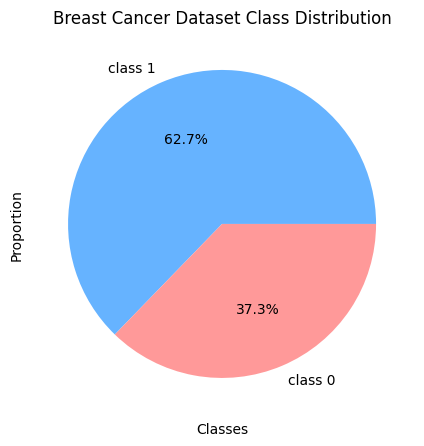

In [18]:
counts = df["target"].value_counts()

plt.figure(figsize=(5, 5))

plt.pie(
    x=counts.values,
    labels=["class " + str(target) for target in counts.keys()],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999']
)

plt.title("Breast Cancer Dataset Class Distribution")

plt.xlabel("Classes")
plt.ylabel("Proportion")

plt.show()

In [19]:
X = df.drop("target", axis=1).values
y = df["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model = AdaBoostClassifier()
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=y_predicted):.4f}")
print(f"Precision: {precision_score(y_true=y_test, y_pred=y_predicted):.4f}")
print(f"Recall: {recall_score(y_true=y_test, y_pred=y_predicted):.4f}")
print(f"F1 Score: {f1_score(y_true=y_test, y_pred=y_predicted):.4f}")

Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790
